In [1]:
import os
import sqlite3
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("✅ Imports done.")


✅ Imports done.


In [3]:
# ============================================
# Step 2 — Generate fake merchant risk data
# Beginner-friendly + Windows-permission-safe
# ============================================

SEED = 42
N_MERCHANTS = 500
DAYS = 180
TXNS_MIN = 150
TXNS_MAX = 600

np.random.seed(SEED)

# ✅ FIX: Set an absolute project folder path (no ".." anywhere)
# IMPORTANT: Change this path to YOUR project folder path
PROJECT_ROOT = Path(r"C:\Users\kjdac\OneDrive\Desktop\MerchantRisk-project")

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = PROJECT_ROOT / "db" / "merchant_risk.db"

# Make folders if they don't exist
DATA_DIR.mkdir(parents=True, exist_ok=True)
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

today = datetime.now().date()
start_date = today - timedelta(days=DAYS)

print("✅ Settings ready.")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DB_PATH:", DB_PATH)
print("Simulating:", N_MERCHANTS, "merchants over", DAYS, "days")


✅ Settings ready.
PROJECT_ROOT: C:\Users\kjdac\OneDrive\Desktop\MerchantRisk-project
DATA_DIR: C:\Users\kjdac\OneDrive\Desktop\MerchantRisk-project\data
DB_PATH: C:\Users\kjdac\OneDrive\Desktop\MerchantRisk-project\db\merchant_risk.db
Simulating: 500 merchants over 180 days


✅ Merchants created: 500


,merchant_id,merchant_name,industry,country,onboard_date,onboarding_channel,latent_risk
0,1,Merchant_0001,travel,US,2025-06-18,sales_assisted,0.375561
1,2,Merchant_0002,travel,US,2025-12-25,sales_assisted,0.272421
2,3,Merchant_0003,marketplace,US,2025-07-30,self_serve,0.431849
3,4,Merchant_0004,fashion,GB,2025-09-19,self_serve,0.179104
4,5,Merchant_0005,electronics,US,2025-10-25,self_serve,0.575764



Latent risk stats:


count    500.000000
mean       0.311856
std        0.156529
min        0.006100
25%        0.193482
50%        0.299031
75%        0.418154
max        0.809442
Name: latent_risk, dtype: float64

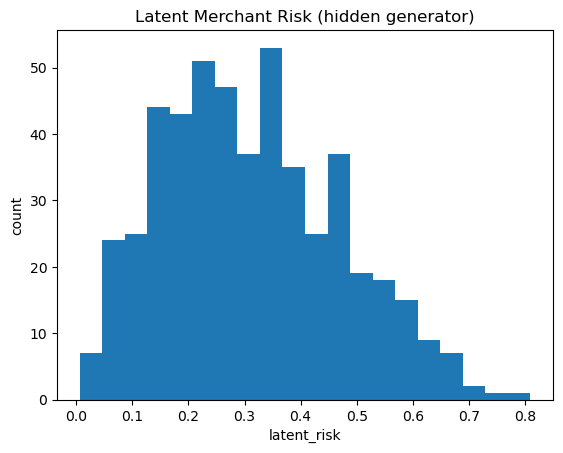

In [4]:
industries = [
    "electronics", "fashion", "beauty", "home_goods", "digital_goods",
    "travel", "supplements", "gaming", "marketplace", "jewelry"
]
countries = ["US", "CA", "GB", "AU"]
channels = ["self_serve", "sales_assisted"]

merchant_ids = np.arange(1, N_MERCHANTS + 1)

# Hidden risk used only to generate realistic patterns
latent_risk = np.random.beta(a=2.2, b=5.0, size=N_MERCHANTS)

merchant_industry = np.random.choice(industries, size=N_MERCHANTS)
merchant_country = np.random.choice(countries, size=N_MERCHANTS, p=[0.72, 0.10, 0.10, 0.08])
merchant_channel = np.random.choice(channels, size=N_MERCHANTS, p=[0.65, 0.35])

# onboard dates over last year
onboard_offsets = np.random.randint(7, 365, size=N_MERCHANTS)
onboard_dates = [(today - timedelta(days=int(x))).isoformat() for x in onboard_offsets]

merchants = pd.DataFrame({
    "merchant_id": merchant_ids,
    "merchant_name": [f"Merchant_{mid:04d}" for mid in merchant_ids],
    "industry": merchant_industry,
    "country": merchant_country,
    "onboard_date": onboard_dates,
    "onboarding_channel": merchant_channel,
    "latent_risk": latent_risk
})

print("✅ Merchants created:", len(merchants))
display(merchants.head())

print("\nLatent risk stats:")
display(merchants["latent_risk"].describe())

plt.figure()
plt.hist(merchants["latent_risk"], bins=20)
plt.title("Latent Merchant Risk (hidden generator)")
plt.xlabel("latent_risk")
plt.ylabel("count")
plt.show()


✅ Transactions created: 184886


,txn_id,merchant_id,customer_id,txn_ts,amount,status,payment_method,device_id,ip_address
0,1,1,132152,2025-10-18 17:58:59,567.42,approved,card,dev_719674,170.110.136.232
1,2,1,125850,2025-09-30 19:27:32,506.08,approved,google_pay,dev_865359,104.172.12.197
2,3,1,69807,2025-11-28 19:53:17,277.63,approved,card,dev_404958,86.238.204.114
3,4,1,38197,2025-12-22 14:56:54,189.21,approved,google_pay,dev_180428,182.215.232.193
4,5,1,44307,2025-11-28 18:42:54,180.65,approved,card,dev_994801,86.182.219.92



Approved vs declined:


status
approved    155555
declined     29331
Name: count, dtype: int64

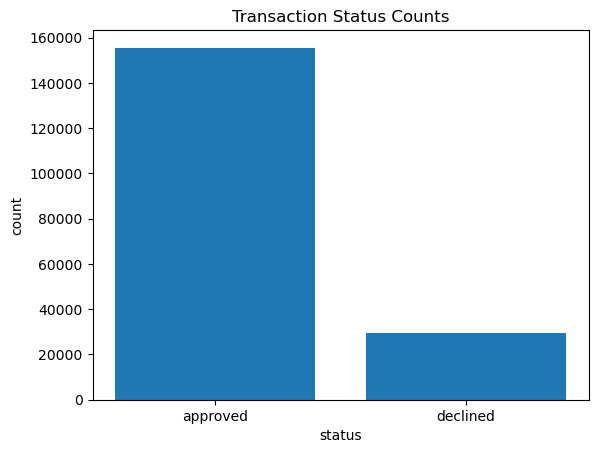

In [5]:
payment_methods = ["card", "ach", "apple_pay", "google_pay"]
pm_probs = [0.75, 0.08, 0.09, 0.08]

def make_device_id():
    return f"dev_{np.random.randint(100000, 999999)}"

def make_ip():
    return f"{np.random.randint(11,240)}.{np.random.randint(0,255)}.{np.random.randint(0,255)}.{np.random.randint(1,254)}"

base_amount_by_industry = {
    "electronics": 120,
    "fashion": 75,
    "beauty": 55,
    "home_goods": 95,
    "digital_goods": 35,
    "travel": 160,
    "supplements": 60,
    "gaming": 45,
    "marketplace": 80,
    "jewelry": 140
}

txn_rows = []
txn_id = 1

for _, m in merchants.iterrows():
    mid = int(m["merchant_id"])
    risk = float(m["latent_risk"])
    industry = m["industry"]

    n_txn = np.random.randint(TXNS_MIN, TXNS_MAX + 1)

    # Higher risk => lower approval probability
    p_approve = 0.95 - 0.35 * risk
    p_approve = max(0.50, min(0.98, p_approve))

    base_amt = base_amount_by_industry[industry]
    mean_amt = base_amt * (1 + 0.25 * risk)
    sigma = 0.60 + 0.25 * risk

    day_offsets = np.random.randint(0, DAYS, size=n_txn)

    for off in day_offsets:
        d = start_date + timedelta(days=int(off))
        hh, mm, ss = np.random.randint(0,24), np.random.randint(0,60), np.random.randint(0,60)
        ts = datetime(d.year, d.month, d.day, hh, mm, ss).isoformat(sep=" ")

        status = "approved" if np.random.rand() < p_approve else "declined"
        pm = np.random.choice(payment_methods, p=pm_probs)
        customer_id = int(np.random.randint(1, 150_000))

        amount = float(np.random.lognormal(mean=np.log(mean_amt), sigma=sigma))
        amount = float(np.clip(amount, 5, 1500))

        txn_rows.append((
            txn_id, mid, customer_id, ts,
            round(amount, 2), status, pm,
            make_device_id(), make_ip()
        ))
        txn_id += 1

transactions = pd.DataFrame(txn_rows, columns=[
    "txn_id", "merchant_id", "customer_id", "txn_ts",
    "amount", "status", "payment_method", "device_id", "ip_address"
])

print("✅ Transactions created:", len(transactions))
display(transactions.head())

print("\nApproved vs declined:")
display(transactions["status"].value_counts())

plt.figure()
counts = transactions["status"].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Transaction Status Counts")
plt.xlabel("status")
plt.ylabel("count")
plt.show()


In [6]:
approved = transactions[transactions["status"] == "approved"].copy()

refund_reasons = ["customer_request", "item_not_received", "duplicate", "merchant_error", "other"]
dispute_reasons = ["fraud", "not_as_described", "item_not_received", "duplicate", "other"]
dispute_outcomes = ["won", "lost", "pending"]

risk_map = merchants.set_index("merchant_id")["latent_risk"].to_dict()

refund_rows = []
dispute_rows = []
refund_id = 1
dispute_id = 1

for _, t in approved.iterrows():
    mid = int(t["merchant_id"])
    risk = float(risk_map[mid])

    p_refund = 0.006 + 0.06 * risk
    p_dispute = 0.002 + 0.03 * risk

    txn_ts = datetime.fromisoformat(t["txn_ts"])
    amount = float(t["amount"])

    if np.random.rand() < p_refund:
        dt = txn_ts + timedelta(days=int(np.random.randint(1, 31)))
        refund_amt = round(amount * np.random.uniform(0.5, 1.0), 2)
        refund_rows.append((refund_id, int(t["txn_id"]), dt.isoformat(sep=" "), refund_amt, np.random.choice(refund_reasons)))
        refund_id += 1

    if np.random.rand() < p_dispute:
        dt = txn_ts + timedelta(days=int(np.random.randint(5, 46)))
        dispute_amt = round(amount * np.random.uniform(0.7, 1.0), 2)

        if risk > 0.75:
            reason = np.random.choice(dispute_reasons, p=[0.45, 0.15, 0.15, 0.10, 0.15])
            outcome = np.random.choice(dispute_outcomes, p=[0.35, 0.50, 0.15])
        else:
            reason = np.random.choice(dispute_reasons, p=[0.20, 0.25, 0.20, 0.10, 0.25])
            outcome = np.random.choice(dispute_outcomes, p=[0.55, 0.30, 0.15])

        dispute_rows.append((dispute_id, int(t["txn_id"]), dt.isoformat(sep=" "), dispute_amt, reason, outcome))
        dispute_id += 1

refunds = pd.DataFrame(refund_rows, columns=["refund_id", "txn_id", "refund_ts", "refund_amount", "reason"])
disputes = pd.DataFrame(dispute_rows, columns=["dispute_id", "txn_id", "dispute_ts", "dispute_amount", "dispute_reason", "outcome"])

print("✅ Refunds created:", len(refunds))
display(refunds.head())

print("✅ Disputes created:", len(disputes))
display(disputes.head())


✅ Refunds created: 3785


,refund_id,txn_id,refund_ts,refund_amount,reason
0,1,3,2025-12-20 19:53:17,139.60,item_not_received
1,2,35,2025-09-29 05:13:07,152.37,item_not_received
2,3,88,2025-11-19 07:59:08,156.62,other
3,4,139,2025-12-11 17:58:00,73.60,item_not_received
4,5,283,2025-09-14 15:14:48,82.95,customer_request


✅ Disputes created: 1711


,dispute_id,txn_id,dispute_ts,dispute_amount,dispute_reason,outcome
0,1,133,2025-11-07 16:28:07,280.40,other,pending
1,2,318,2025-11-23 18:23:44,538.94,item_not_received,lost
2,3,464,2025-12-04 05:04:13,202.94,other,won
3,4,747,2025-12-20 02:04:08,165.88,other,won
4,5,801,2025-12-25 01:12:59,35.71,item_not_received,lost


In [7]:
merchants.to_csv(DATA_DIR / "merchants.csv", index=False)
transactions.to_csv(DATA_DIR / "transactions.csv", index=False)
refunds.to_csv(DATA_DIR / "refunds.csv", index=False)
disputes.to_csv(DATA_DIR / "disputes.csv", index=False)

print("✅ CSVs saved into:", DATA_DIR)


✅ CSVs saved into: C:\Users\kjdac\OneDrive\Desktop\MerchantRisk-project\data


In [8]:
# merchants table in DB should not include latent_risk
merchants_for_db = merchants.drop(columns=["latent_risk"]).copy()

con = sqlite3.connect(DB_PATH)
cur = con.cursor()

cur.executescript("""
PRAGMA foreign_keys = ON;

CREATE TABLE IF NOT EXISTS merchants (
  merchant_id INTEGER PRIMARY KEY,
  merchant_name TEXT NOT NULL,
  industry TEXT NOT NULL,
  country TEXT NOT NULL,
  onboard_date TEXT NOT NULL,
  onboarding_channel TEXT NOT NULL
);

CREATE TABLE IF NOT EXISTS transactions (
  txn_id INTEGER PRIMARY KEY,
  merchant_id INTEGER NOT NULL,
  customer_id INTEGER NOT NULL,
  txn_ts TEXT NOT NULL,
  amount REAL NOT NULL,
  status TEXT NOT NULL,
  payment_method TEXT NOT NULL,
  device_id TEXT NOT NULL,
  ip_address TEXT NOT NULL,
  FOREIGN KEY (merchant_id) REFERENCES merchants(merchant_id)
);

CREATE TABLE IF NOT EXISTS refunds (
  refund_id INTEGER PRIMARY KEY,
  txn_id INTEGER NOT NULL,
  refund_ts TEXT NOT NULL,
  refund_amount REAL NOT NULL,
  reason TEXT NOT NULL,
  FOREIGN KEY (txn_id) REFERENCES transactions(txn_id)
);

CREATE TABLE IF NOT EXISTS disputes (
  dispute_id INTEGER PRIMARY KEY,
  txn_id INTEGER NOT NULL,
  dispute_ts TEXT NOT NULL,
  dispute_amount REAL NOT NULL,
  dispute_reason TEXT NOT NULL,
  outcome TEXT NOT NULL,
  FOREIGN KEY (txn_id) REFERENCES transactions(txn_id)
);
""")

# clear old data so reruns are clean
cur.executescript("""
DELETE FROM disputes;
DELETE FROM refunds;
DELETE FROM transactions;
DELETE FROM merchants;
""")
con.commit()

merchants_for_db.to_sql("merchants", con, if_exists="append", index=False)
transactions.to_sql("transactions", con, if_exists="append", index=False)
refunds.to_sql("refunds", con, if_exists="append", index=False)
disputes.to_sql("disputes", con, if_exists="append", index=False)
con.commit()

cur.executescript("""
CREATE INDEX IF NOT EXISTS idx_txn_merchant_ts ON transactions(merchant_id, txn_ts);
CREATE INDEX IF NOT EXISTS idx_txn_status ON transactions(status);
CREATE INDEX IF NOT EXISTS idx_refunds_txn ON refunds(txn_id);
CREATE INDEX IF NOT EXISTS idx_disputes_txn ON disputes(txn_id);
""")
con.commit()

counts = pd.read_sql_query("""
SELECT 'merchants' AS table_name, COUNT(*) AS n FROM merchants
UNION ALL SELECT 'transactions', COUNT(*) FROM transactions
UNION ALL SELECT 'refunds', COUNT(*) FROM refunds
UNION ALL SELECT 'disputes', COUNT(*) FROM disputes;
""", con)

print("✅ Loaded into SQLite. Row counts:")
display(counts)

con.close()


✅ Loaded into SQLite. Row counts:


,table_name,n
0,merchants,500
1,transactions,184886
2,refunds,3785
3,disputes,1711


In [9]:
con = sqlite3.connect(DB_PATH)

bad_refunds = pd.read_sql_query("""
SELECT COUNT(*) AS bad_refund_links
FROM refunds r
LEFT JOIN transactions t ON r.txn_id = t.txn_id
WHERE t.txn_id IS NULL;
""", con)

bad_disputes = pd.read_sql_query("""
SELECT COUNT(*) AS bad_dispute_links
FROM disputes d
LEFT JOIN transactions t ON d.txn_id = t.txn_id
WHERE t.txn_id IS NULL;
""", con)

refund_over = pd.read_sql_query("""
SELECT COUNT(*) AS refunds_over_txn
FROM refunds r
JOIN transactions t ON r.txn_id = t.txn_id
WHERE r.refund_amount > t.amount;
""", con)

dispute_over = pd.read_sql_query("""
SELECT COUNT(*) AS disputes_over_txn
FROM disputes d
JOIN transactions t ON d.txn_id = t.txn_id
WHERE d.dispute_amount > t.amount;
""", con)

print("Sanity checks (these should be 0):")
display(bad_refunds)
display(bad_disputes)
display(refund_over)
display(dispute_over)

rates = pd.read_sql_query("""
WITH approved AS (SELECT txn_id FROM transactions WHERE status='approved'),
approved_ct AS (SELECT COUNT(*) AS approved FROM approved),
refund_ct AS (SELECT COUNT(*) AS refunds FROM refunds),
dispute_ct AS (SELECT COUNT(*) AS disputes FROM disputes)
SELECT
  approved_ct.approved AS approved_txns,
  refund_ct.refunds AS refunds,
  dispute_ct.disputes AS disputes,
  ROUND(1.0 * refund_ct.refunds / approved_ct.approved, 4) AS refund_rate_on_approved,
  ROUND(1.0 * dispute_ct.disputes / approved_ct.approved, 4) AS dispute_rate_on_approved
FROM approved_ct, refund_ct, dispute_ct;
""", con)

print("\nOverall rates:")
display(rates)

con.close()
print("✅ Done.")


Sanity checks (these should be 0):


,bad_refund_links
0,0


,bad_dispute_links
0,0


,refunds_over_txn
0,0


,disputes_over_txn
0,0



Overall rates:


,approved_txns,refunds,disputes,refund_rate_on_approved,dispute_rate_on_approved
0,155555,3785,1711,0.0243,0.011


✅ Done.
